In [1]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random


In [2]:
np.random.seed(42)

N_NORMAL = 1000
N_ANOMALIE = 50

In [6]:
def generate_normal_data(n):
    data = {
        'date': pd.date_range(start='2024-01-01', end='2024-12-31', periods=n),
        'montant': np.random.randint(5000, 500000, n),
        'quantite': np.random.randint(1, 100, n),
        'heure': np.random.randint(8, 20, n),
        'type_transaction': random.choices(['vente', 'achat', 'remboursement'], k=n),
        'is_anomalie': [0] * n
    }
    return pd.DataFrame(data)


Gerer les anomalies

In [7]:
def generate_anomalie_data(n):
    data = {
        'date': pd.date_range(start='2025-01-01', end='2025-12-31', periods=n),
        'montant': np.random.randint(2000000, 5000000, n),
        'quantite': np.random.randint(500, 1000, n),
        'heure': np.random.randint(0, 5, n),
        'type_transaction': random.choices(['vente', 'achat', 'remboursement'], k=n),
        'is_anomalie': [1] * n
    }
    return pd.DataFrame(data)


In [11]:
if __name__ == "__main__":
    normal = generate_normal_data(N_NORMAL)
    anomalies = generate_anomalie_data(N_ANOMALIE)

    dataset = pd.concat([normal, anomalies], ignore_index=True)
    dataset = dataset.sample(frac=1).reset_index(drop=True)

    import os
    os.makedirs('ml/datasets', exist_ok=True)
    dataset.to_csv('klaaro_dataset.csv', index=False)
    print(f"Dataset généré : {len(dataset)} lignes")

Dataset généré : 1050 lignes


In [12]:
import pandas as pd
import matplotlib.pyplot as plt


                         date  montant  quantite  heure type_transaction  \
0  2024-03-22 20:12:15.135135   354627        77     16    remboursement   
1  2024-09-16 18:35:40.540540    46340        64     12            achat   
2  2024-03-09 16:31:42.702702   356664        38     13    remboursement   
3  2024-09-16 09:49:32.972972   267070        55     16            achat   
4  2024-08-13 10:19:49.189189   403422        23     11            vente   

   is_anomalie  
0            0  
1            0  
2            0  
3            0  
4            0  

Distribution : is_anomalie
0    1000
1      50
Name: count, dtype: int64


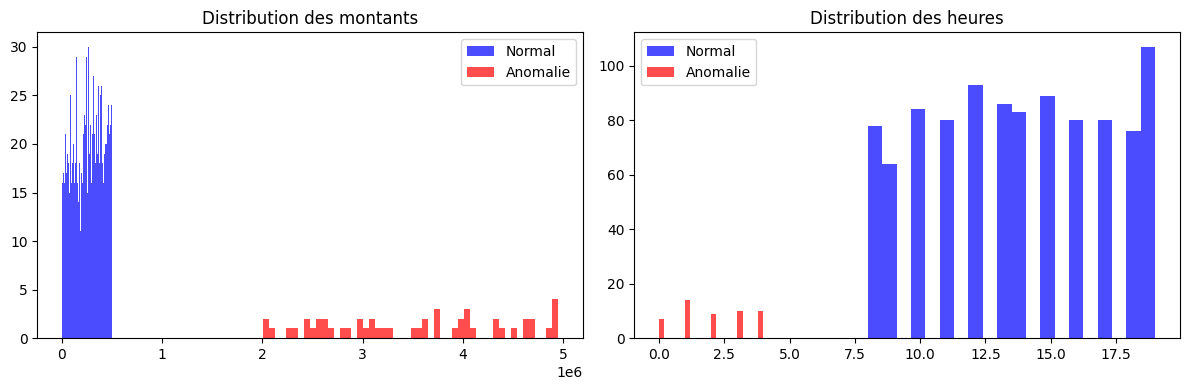

In [13]:

# Charger le dataset
df = pd.read_csv('klaaro_dataset.csv')

# Afficher les premières lignes
print(df.head())
print(f"\nDistribution : {df['is_anomalie'].value_counts()}")

# Visualiser les montants
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.hist(df[df['is_anomalie']==0]['montant'], bins=50, color='blue', alpha=0.7, label='Normal')
plt.hist(df[df['is_anomalie']==1]['montant'], bins=50, color='red', alpha=0.7, label='Anomalie')
plt.legend()
plt.title('Distribution des montants')

plt.subplot(1, 2, 2)
plt.hist(df[df['is_anomalie']==0]['heure'], bins=20, color='blue', alpha=0.7, label='Normal')
plt.hist(df[df['is_anomalie']==1]['heure'], bins=20, color='red', alpha=0.7, label='Anomalie')
plt.legend()
plt.title('Distribution des heures')

plt.tight_layout()
plt.show()

In [10]:
import os
print(os.getcwd())

/home/marina/Documents/Meee/Stage L3/klaaro_backend/ml/datasets
